In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/content/bank_transactions_1000.csv')

In [6]:
df.head()

,Transaction_ID,Customer_ID,City,Transaction_Type,Merchant_Category,Transaction_Amount,Transaction_Status,Transaction_Time,Suspicious_Flag
0,TXN100000,1102,Hyderabad,NEFT,Entertainment,166992,Pending,12-03-2025 12:51,Yes
1,TXN100001,1435,Hyderabad,UPI,Travel,66362,Success,04-05-2025 04:28,No
2,TXN100002,1860,Kolkata,NEFT,Healthcare,134932,Failed,23-05-2025 03:46,Yes
3,TXN100003,1270,Ahmedabad,Debit Card,Food,153362,Success,23-06-2025 19:18,Yes
4,TXN100004,1106,Mumbai,Net Banking,Healthcare,67511,Success,16-04-2025 20:36,No


In [8]:
# cities with highest transaction volume
city_volume = df.groupby('City')['Transaction_Amount'].sum().sort_values(ascending=False)
city_volume

,Transaction_Amount
City,
Mumbai,15622147
Chennai,13742995
Pune,13560484
Delhi,13192139
Hyderabad,13142129
Kolkata,12368561
Bangalore,10294471
Ahmedabad,9808632


In [13]:
# Identify unusually high transactions
high_transactions = df[df['Transaction_Amount'] > df['Transaction_Amount'].mean()]
high_transactions

,Transaction_ID,Customer_ID,City,Transaction_Type,Merchant_Category,Transaction_Amount,Transaction_Status,Transaction_Time,Suspicious_Flag
0,TXN100000,1102,Hyderabad,NEFT,Entertainment,166992,Pending,12-03-2025 12:51,Yes
2,TXN100002,1860,Kolkata,NEFT,Healthcare,134932,Failed,23-05-2025 03:46,Yes
3,TXN100003,1270,Ahmedabad,Debit Card,Food,153362,Success,23-06-2025 19:18,Yes
6,TXN100006,1700,Mumbai,Net Banking,Healthcare,177909,Success,29-01-2025 19:24,Yes
10,TXN100010,1466,Mumbai,NEFT,Shopping,148149,Success,03-02-2025 12:42,Yes
...,...,...,...,...,...,...,...,...,...
992,TXN100992,1814,Kolkata,Debit Card,Food,149796,Success,25-06-2025 00:48,Yes
994,TXN100994,1449,Pune,NEFT,Food,110003,Success,14-05-2025 13:49,Yes
995,TXN100995,1009,Mumbai,Credit Card,Entertainment,131561,Success,15-06-2025 09:23,Yes
997,TXN100997,1797,Pune,NEFT,Travel,114003,Success,15-03-2025 16:54,Yes


In [17]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'City', 'Transaction_Type',
       'Merchant_Category', 'Transaction_Amount', 'Transaction_Status',
       'Transaction_Time', 'Suspicious_Flag'],
      dtype='object')

In [15]:
df['Transaction_Amount'].mean()

np.float64(101731.558)

In [19]:
# Analyze peak transaction hours
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], format='%d-%m-%Y %H:%M')
df['Transaction_Hour'] = df['Transaction_Time'].dt.hour
peak_hours = df.groupby('Transaction_Hour')['Transaction_Amount'].sum().sort_values(ascending=False)
peak_hours

,Transaction_Amount
Transaction_Hour,
21,5906590
6,5573596
2,5290197
14,5197944
13,5029768
5,4961519
17,4958359
12,4634751
19,4502069


In [21]:
# Detect suspicious transaction patterns
suspicious_transactions = df[df['Suspicious_Flag'] == 'Yes']
display(suspicious_transactions.head())
display(suspicious_transactions.describe())

,Transaction_ID,Customer_ID,City,Transaction_Type,Merchant_Category,Transaction_Amount,Transaction_Status,Transaction_Time,Suspicious_Flag,Transaction_Hour
0,TXN100000,1102,Hyderabad,NEFT,Entertainment,166992,Pending,2025-03-12 12:51:00,Yes,12
2,TXN100002,1860,Kolkata,NEFT,Healthcare,134932,Failed,2025-05-23 03:46:00,Yes,3
3,TXN100003,1270,Ahmedabad,Debit Card,Food,153362,Success,2025-06-23 19:18:00,Yes,19
6,TXN100006,1700,Mumbai,Net Banking,Healthcare,177909,Success,2025-01-29 19:24:00,Yes,19
10,TXN100010,1466,Mumbai,NEFT,Shopping,148149,Success,2025-02-03 12:42:00,Yes,12


,Customer_ID,Transaction_Amount,Transaction_Time,Transaction_Hour
count,514.000000,514.000000,514,514.000000
mean,1506.887160,150669.071984,2025-03-30 02:13:03.735408384,11.624514
min,1000.000000,100031.000000,2025-01-01 06:56:00,0.000000
25%,1244.750000,128688.000000,2025-02-10 15:32:15,5.000000
50%,1508.500000,151391.000000,2025-03-26 20:13:00,12.000000
75%,1758.250000,173986.750000,2025-05-13 12:27:00,17.000000
max,1998.000000,199875.000000,2025-06-29 21:29:00,23.000000
std,291.726452,27513.104038,NaN,6.959438


visualization

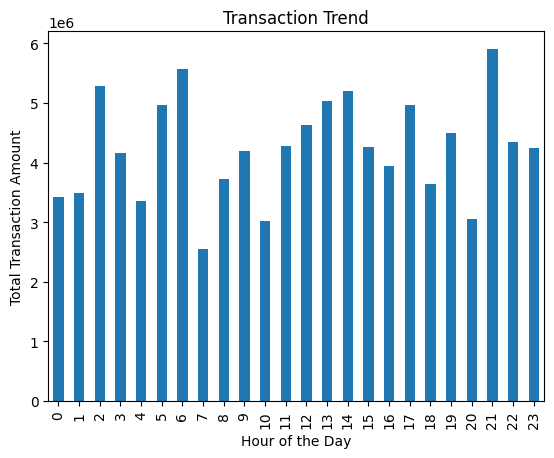

In [22]:
# transaction trend charts
df.groupby('Transaction_Hour')['Transaction_Amount'].sum().plot(kind='bar', title='Transaction Trend')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Transaction Amount')
plt.show()

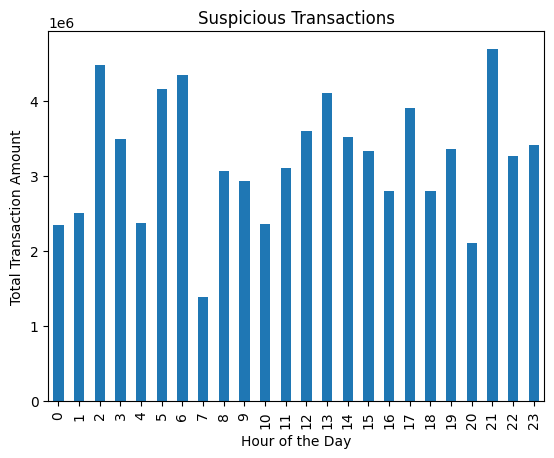

In [23]:
# fraud detection visualizations
suspicious_transactions.groupby('Transaction_Hour')['Transaction_Amount'].sum().plot(kind='bar', title='Suspicious Transactions')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Transaction Amount')
plt.show()

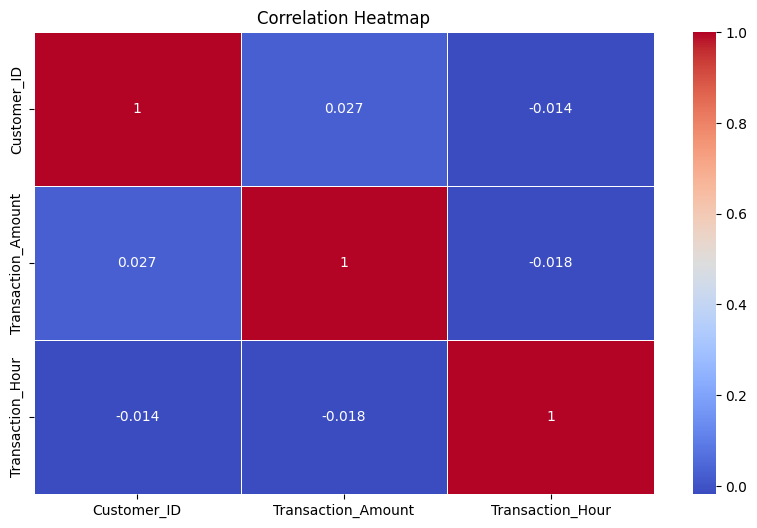

In [25]:
# heatmaps
corr = df.corr(numeric_only= True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [26]:
# Suggest fraud prevention strategies
print('Monitor unusually large transactions')
print('Use real-time fraud detection systems')
print('Flag abnormal night-time transactions')
print('Apply multi-factor authentication')

Monitor unusually large transactions
Use real-time fraud detection systems
Flag abnormal night-time transactions
Apply multi-factor authentication
